##  TRABAJO PRACTICO N° 2 : Regresiones

## 1. MODULOS

In [ ]:
# Importación Modulos #

#Modulos Generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Polinomial
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import metrics
from sklearn.model_selection import train_test_split

#Regresion lineal multiple
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#Regresion Logistica
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import fbeta_score, accuracy_score, f1_score, precision_score, recall_score


## 2. DATAFRAME

In [ ]:
# Vinculo Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Lectura de los datos Cuando el csv no esta separado por , usar sep= para describir el tipo de separador
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bases de datos/data_sample.csv', sep= ";")
df.head()

,customer_id,customer_size,digital_tenure_months,share_digital_orders,assortment_coverage,minutes_on_site,avg_minutes_per_page,unique_pages_visited,add_to_cart_count,revome_from_cart_count,minutes_purchase,suggested_purchase
0,1,Medium,6,88.888889,0.064516,51.914457,2.732340,10.0,3.0,0.0,5.0,0
1,2,Medium,9,100.000000,0.074390,75.566683,0.706231,13.0,32.0,0.0,62.0,0
2,3,Medium,12,50.000000,0.083777,50.861066,0.876915,14.0,22.0,0.0,31.0,0
3,4,Small,9,75.000000,0.042476,120.077884,13.341987,7.0,3.0,13.0,1.0,1
4,5,Large,6,75.000000,0.089535,21.776023,1.036953,9.0,10.0,0.0,8.0,0


In [ ]:
df = df.rename(columns= {
    'customer_id': 'cliente_id',
    'customer_size': 'cliente_tamaño',
    'digital_tenure_months': 'ant_meses',
    'share_digital_orders': 'porc_compra_dig',
    'assortment_coverage': 'porc_cobertura_surtido',
    'minutes_on_site': 'minutos_plat',
    'avg_minutes_per_page': 'min_pagina',
    'unique_pages_visited':'visitas_unicas',
    'add_to_cart_count': 'prod_agregados',
    'remove_from_cart': 'prod_removidos',
    'minutes_purchase': 'duracion_compra',
    'suggested_purchase': 'compra_realizada'
})

## Descripcion de los datos

| Variable                         | Tipo de dato | Descripción                                                                                  |
| -------------------------------- | ------------ | -------------------------------------------------------------------------------------------- |
| **cliente_id**                   | int64        | Identificador único del cliente.                                                             |
| **cliente_tamaño**               | object       | Tamaño del cliente (por ejemplo, pequeño, mediano o grande).                                 |
| **antiguedad_meses**             | int64        | Meses de antigüedad digital (tiempo desde la primera compra digital).                        |
| **porcentaje_compras_dig**       | float64      | Proporción de compras digitales sobre el total de compras.                                   |
| **porcentage_cobertura_surtido** | float64      | Nivel de cobertura del surtido usual respecto al portafolio disponible.                      |
| **minutos_platform**             | float64      | Minutos totales que el cliente pasó en la plataforma.                                        |
| **minutos_por_pagina**           | float64      | Promedio de minutos por página en la plataforma.                                             |
| **visitas_unicas**               | float64      | Cantidad de páginas únicas visitadas por el cliente.                                         |
| **productos_agregados**          | float64      | Número de productos agregados al carrito en la plataforma.                                   |
| **productos_removidos**          | float64      | Número de productos removidos del carrito.                                                   |
| **duracion_compra**              | float64      | Duración total (en minutos) de la sesión de compra.                                          |
| **compra_realizada**             | int64        | Indica si la compra fue realizada a través de la página de recomendaciones (1 = sí, 0 = no). |


In [ ]:
# Para analizar un poco las medidas en las que vamos a trabajar
df.describe()

,cliente_id,ant_meses,porc_compra_dig,porc_cobertura_surtido,minutos_plat,min_pagina,visitas_unicas,prod_agregados,revome_from_cart_count,duracion_compra,compra_realizada
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,6.530000,76.101279,0.100739,90.190075,3.401254,11.013333,12.870000,3.510000,16.376111,0.100000
std,86.746758,3.275903,16.422725,0.082146,170.137405,6.888179,3.004983,10.648838,5.919462,14.414251,0.300501
min,1.000000,0.000000,25.000000,0.010369,1.650762,0.135058,5.000000,2.000000,0.000000,1.000000,0.000000
25%,75.750000,4.000000,66.666667,0.048288,11.057459,0.456320,9.000000,6.000000,0.000000,6.000000,0.000000
50%,150.500000,6.000000,75.000000,0.074762,22.544203,0.847572,11.000000,9.000000,1.000000,12.000000,0.000000
75%,225.250000,9.000000,83.333333,0.124816,74.498591,2.317476,13.000000,16.000000,5.000000,22.000000,0.000000
max,300.000000,15.000000,100.000000,0.578431,1109.440232,50.253500,23.000000,67.000000,52.000000,74.000000,1.000000


In [ ]:
df.head()

,cliente_id,cliente_tamaño,ant_meses,porc_compra_dig,porc_cobertura_surtido,minutos_plat,min_pagina,visitas_unicas,prod_agregados,revome_from_cart_count,duracion_compra,compra_realizada
0,1,Medium,6,88.888889,0.064516,51.914457,2.732340,10.0,3.0,0.0,5.0,0
1,2,Medium,9,100.000000,0.074390,75.566683,0.706231,13.0,32.0,0.0,62.0,0
2,3,Medium,12,50.000000,0.083777,50.861066,0.876915,14.0,22.0,0.0,31.0,0
3,4,Small,9,75.000000,0.042476,120.077884,13.341987,7.0,3.0,13.0,1.0,1
4,5,Large,6,75.000000,0.089535,21.776023,1.036953,9.0,10.0,0.0,8.0,0


from matplotlib import pyplot as plt
_df_21['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_22['cliente_id'].plot(kind='hist', bins=20, title='cliente_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_23['ant_meses'].plot(kind='hist', bins=20, title='ant_meses')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_24['porc_compra_dig'].plot(kind='hist', bins=20, title='porc_compra_dig')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_39['cliente_tamaño'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_39, x='cliente_id', y='cliente_tamaño', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_40['cliente_tamaño'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_40, x='ant_meses', y='cliente_tamaño', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_41['cliente_tamaño'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_41, x='porc_compra_dig', y='cliente_tamaño', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

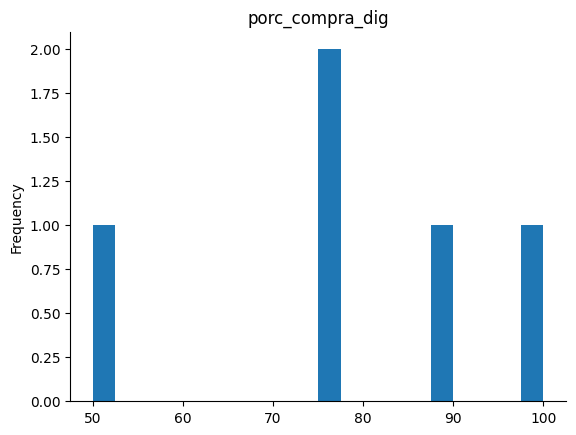

In [ ]:
from matplotlib import pyplot as plt
_df_24['porc_compra_dig'].plot(kind='hist', bins=20, title='porc_compra_dig')
plt.gca().spines[['top', 'right',]].set_visible(False)

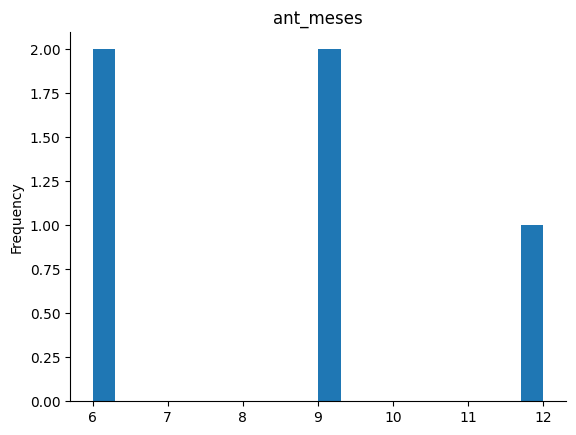

In [ ]:
from matplotlib import pyplot as plt
_df_23['ant_meses'].plot(kind='hist', bins=20, title='ant_meses')
plt.gca().spines[['top', 'right',]].set_visible(False)

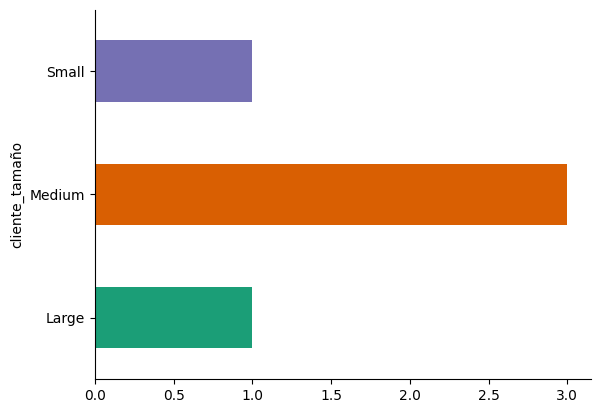

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_25.groupby('cliente_tamaño').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Medida categorica tamaño cliente
df['cliente_tamaño'].value_counts()

,count
cliente_tamaño,
Small,96
Medium,75
Large,68
Very Large,61


In [ ]:
# Dato que me gustaria tener en consideracion son las cantidad de interacciones digitales que finalizaron como compras
total_compras_realizadas = (df['compra_realizada'] == 1).sum()
print("Total de compras realizadas: ", total_compras_realizadas)

Total de compras realizadas:  30


## 3. Modelo de Regresion Polinomico ##

Previo a comenzar con con el analisis, es necesario tener en consideracion el modelo de regresion polinomico que utlizaremos para predecir segun la antiguedad que lleva utilizando la plataforma cual es su nivel de compras en consideracion a las compras totales que realiza.

La formula del modelo en cuestion:

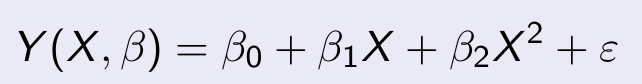

A partir de este modelo desarrollaremos los siguientes pasos:

Crearemos una regresion polinomica, utilizando los modulos planteados al principio, con ello se eligirá evaluando el error cuadrático medio al enternar los modelos considerando las distintas alternativas.
Se llevara adelante utilizando la función PolynomialFeatures y make_pipeline  que nos permitirá evaluar el error en distintos grados de polinomio para poder guardar las métricas consideradas para posteriormente poder compararlas.

In [ ]:
# Division de conjuntos para validacion y entrenamiento
features = ['ant_meses']
X = df[features]
y = df['porc_compra_dig']

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=1234)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.20, shuffle=True, random_state=1234)

print('X_train:', X_train.shape)
print('X_val:',  X_test.shape)
print('X_test:',  X_test.shape)
print('y_train:', y_train.shape)
print('y_val:', y_test.shape)
print('y_test:', y_test.shape)


X_train: (192, 1)
X_val: (60, 1)
X_test: (60, 1)
y_train: (192,)
y_val: (60,)
y_test: (60,)


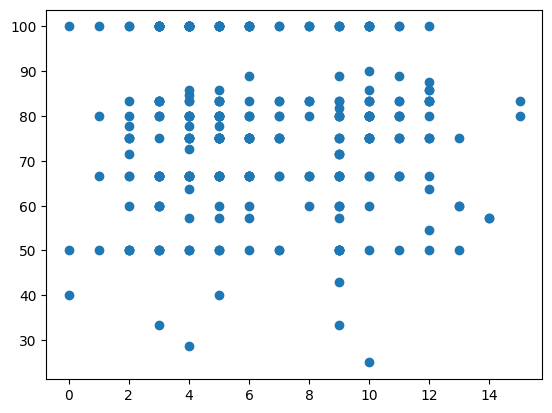

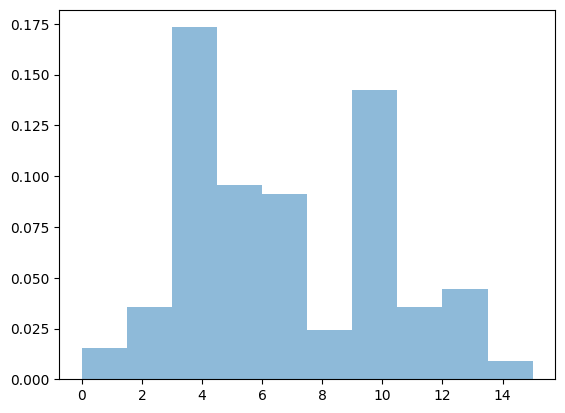

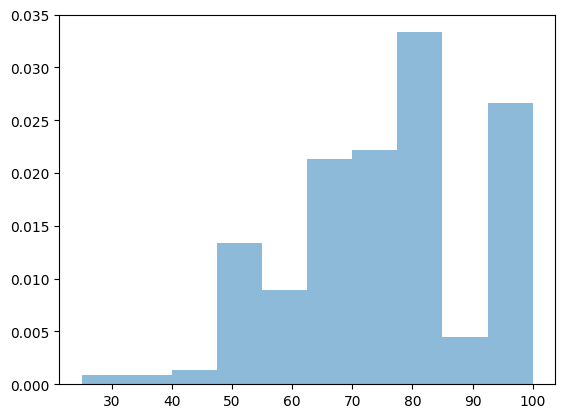

In [ ]:
# Distibucion univaria de ambos elementos
plt.scatter(X,y)
plt.show()

#Histograma de las medidas Antiguedad y Porcentaje de Compras
plt.hist(X, alpha=0.5, density=True, label='Antiguedad')
plt.show()
plt.hist(y, alpha=0.5, density=True, label='Compras')
plt.show()

In [ ]:
# En las siguientes listas se guardará los errores en el conjunto de entrenamiento y el de validación
train_errors = []
val_errors = []

#degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9]
degrees =  list(range(1, 30))
for M in degrees:
  # Usar PolynomialFeatures y LinearRegression para construir el modelo polinomico
    pf = PolynomialFeatures(M)
    lr = LinearRegression()
    # Usar make_pipeline paa crear y ajustar el modelo
    model = make_pipeline(pf, lr)
    model.fit(X_train, y_train)
    # Generar las predicciones
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    ### Evaluar ###
    # Utilizaremos la medida Mean Squared Error para medir el ajuste del modelo de regresion
    train_error = mean_squared_error(y_train, y_train_pred)
    val_error = mean_squared_error(y_val, y_val_pred)
    train_errors.append(train_error)
    val_errors.append(val_error)

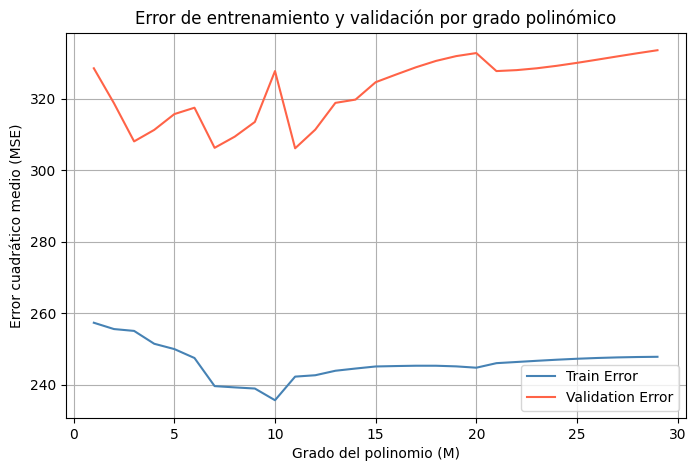

In [ ]:
# Grafico Descriptivo
plt.figure(figsize=(8, 5))
plt.plot(degrees[:len(train_errors)], train_errors, color="steelblue", label="Train Error")
plt.plot(degrees[:len(val_errors)], val_errors, color="tomato", label="Validation Error")
plt.xlabel("Grado del polinomio (M)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Error de entrenamiento y validación por grado polinómico")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
M = 2
pf = PolynomialFeatures(M)
lr = LinearRegression()
model = make_pipeline(pf, lr)
model.fit(X_trainval, y_trainval)

y_test_pred = model.predict(X_test)
test_err_sq = mean_squared_error(y_test, y_test_pred)
test_err_abs = metrics.mean_absolute_error(y_test, y_test_pred)

print('MAE:', test_err_abs)
print('MSE:', test_err_sq)

MAE: 13.48365439095841
MSE: 263.2452165274338


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


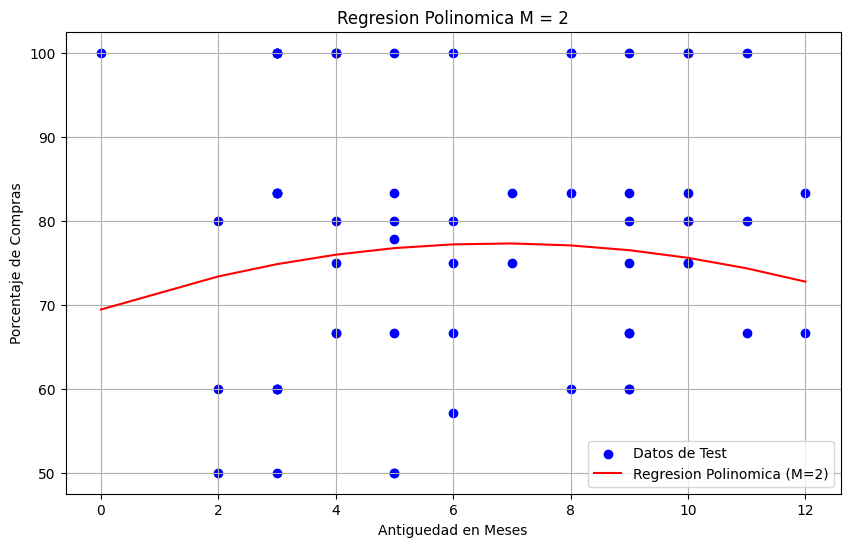

In [ ]:
# Con esto queremos visualizar que tanto se ajusta nuestro modelo regresivo con los datos dados
X_test_sorted = np.sort(X_test.values, axis=0)
y_test_pred_sorted = model.predict(X_test_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos de Test') # Los valores del conjunto de datos de test estaran en azul
plt.plot(X_test_sorted, y_test_pred_sorted, color='red', label=f'Regresion Polinomica (M={M})') # La regresion lineal polimonica de los datos predictivos en M=5 estaran en rojo
plt.xlabel('Antiguedad en Meses')
plt.ylabel('Porcentaje de Compras')
plt.title(f'Regresion Polinomica M = {M}')
plt.legend()
plt.grid(True)
plt.show()

## 4. Modelo Regresion Lineal Multiple ##

Con la motivacion de llegar a nuevas conclusiones sobre nuestra problematica, utilizaremos el modelo de **Regresion Lineal Multiple**, para por medio de nuevos atributos del dataset poder arribar a nuevas predicciones sobre el procentaje de ventas con la nueva plataforma online.

La formula del modelo sobre la que trabajaremos:

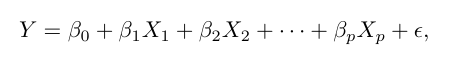

In [ ]:
#Creacion de los subconjuntos para la utilizacion del modelo

features1 = ['ant_meses','porc_cobertura_surtido','minutos_plat','duracion_compra','compra_realizada']
X = df[features1]
y = df['porc_compra_dig']

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=1234)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.20, shuffle=True, random_state=1234)

print('X_train:', X_train.shape)
print('X_val:',  X_test.shape)
print('X_test:',  X_test.shape)
print('y_train:', y_train.shape)
print('y_val:', y_test.shape)
print('y_test:', y_test.shape)

X_train: (192, 5)
X_val: (60, 5)
X_test: (60, 5)
y_train: (192,)
y_val: (60,)
y_test: (60,)


In [ ]:
#Modelo de Regresion Multiple
model = LinearRegression()
model.fit(X_trainval, y_trainval)

y_test_pred = model.predict(X_test)
test_err_sq = mean_squared_error(y_test, y_test_pred)
test_err_abs = metrics.mean_absolute_error(y_test, y_test_pred)

print('MAE:', test_err_abs)
print('MSE', test_err_sq)

MAE: 13.091819872557275
MSE 238.5776677791632


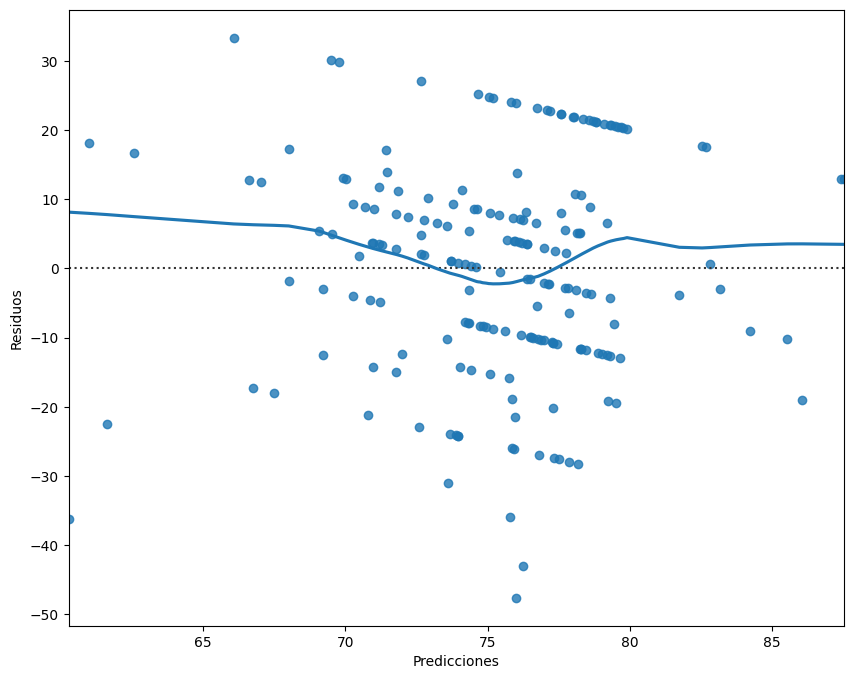

In [ ]:
#Obtenemos los valores residuos del modelo (errores del modelo) en funcion de las predicciones:
def residplot(model,X,y,**kwargs):
  vals = {'Residuos': y-model.predict(X), 'Predicciones': model.predict(X)}  # Residu
  resdf = pd.DataFrame(vals)
  ax = sns.residplot(y='Residuos',x='Predicciones', data=resdf, **kwargs)
  return ax

#Grafico de los Residuos del modelo
fig, ax = plt.subplots()
fig.set_size_inches(10,8)
residplot(model, X_train, y_train, lowess = True)
plt.show()

#La linea azul muestra la tendendia promedio de los residuos
#La linea punteada en Y=0 incida el punto donde el error seria nulo, es decir la prediccion seria perfecta

In [ ]:
predictions = model.predict(X_test)

# Si hay predicciones negativas, las igualamos a 0
for i,num in enumerate(predictions):
    if num<0:
        predictions[i] = 0

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('RMSLE:', np.sqrt(metrics.mean_squared_log_error(y_test, predictions)))

MAE: 13.091819872557275
MSE: 238.5776677791632
RMSE: 15.445959593989723
RMSLE: 0.1990660215964266


| Métrica                                                 | Valor  | Interpretación                                                                                |
| ------------------------------------------------------- | ------ | --------------------------------------------------------------------------------------------- |
| **MAE (Error Absoluto Medio)**                          | 13.09  | En promedio, las predicciones se desvían **13 unidades** del valor real.                      |
| **MSE (Error Cuadrático Medio)**                        | 238.58 | Mide el error promedio al cuadrado. Penaliza más los errores grandes.                         |
| **RMSE (Raíz del MSE)**                                 | 15.45  | Error promedio expresado en la misma escala que la variable objetivo.                         |
| **RMSLE (Raíz del Error Logarítmico Cuadrático Medio)** | 0.199  | Indica que el error relativo es bajo; útil si los valores predichos varían mucho en magnitud. |


## 5. Eleccion de Modelo


In [ ]:
# Comparacion de la Erro Cuadratico Medio

# Regresión Polinómica:
mae_polinomica = 13.477314054611808
mse_polinomica = 278.9977296120426

# Regresión Lineal Múltiple:
mae_multiple = 13.091819872557275
mse_multiple = 238.5776677791632


data_mse = {
    'Modelo': ['Polinómica (M=2)', 'Lineal Múltiple'],
    'MAE': [mae_polinomica, mae_multiple],
    'MSE': [mse_polinomica, mse_multiple]
}

df_comparativa_mse = pd.DataFrame(data_mse)

# Ordenar por el error más bajo (MSE, menor es mejor)
df_comparativa_mse = df_comparativa_mse.sort_values(by='MSE', ascending=True).reset_index(drop=True)

print("--- Comparativa de Modelos basada ÚNICAMENTE en MSE ---")
print(df_comparativa_mse.to_markdown(index=False, floatfmt=".1f"))

# Identificar el mejor modelo
mejor_mse = df_comparativa_mse.iloc[0]['Modelo']
print(f"\n El mejor modelo según el Error Cuadrático Medio (MSE) es: {mejor_mse}")

--- Comparativa de Modelos basada ÚNICAMENTE en MSE ---
| Modelo           |   MAE |   MSE |
|:-----------------|------:|------:|
| Lineal Múltiple  |  13.1 | 238.6 |
| Polinómica (M=2) |  13.5 | 279.0 |

 El mejor modelo según el Error Cuadrático Medio (MSE) es: Lineal Múltiple


## 6. Regresion Logistica

En esta instancia elegiremos como variable dicotomica es si compra fue realizada y las variables predictoras que nos conduciaran al analisis de las mismas son el tamaño de la organizacion,porcentaje de compras, el porcentaje de cobertura que utiliza de nuestro inventario, la duracion de la compras y los productor agregados.

La formula del modelo1 a utilizar es:
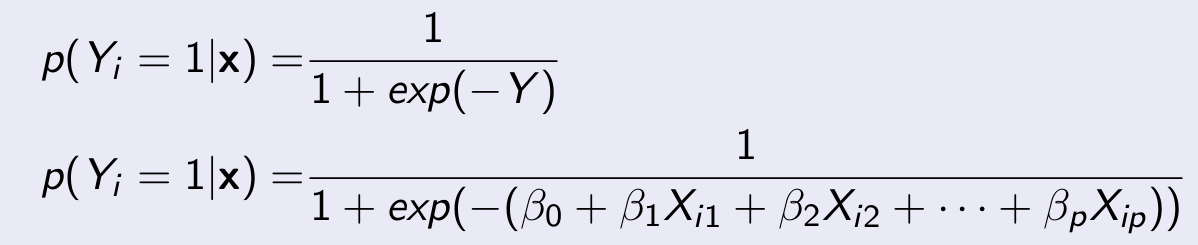

La formula y criterio a tener en cuenta para el modelo 2:
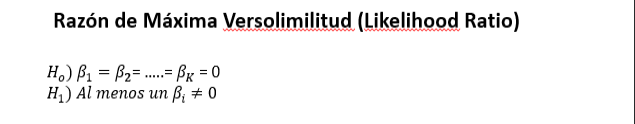

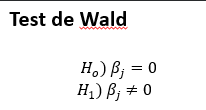

Mediante estos modelos de regresion se busca estimar la probabilidad de que una observacion asuma una categoria determinada, dado los valores de las variables predictoras.

In [ ]:
#Desarrollo del modelo logistico
modelo1 = smf.logit(formula = 'compra_realizada ~ cliente_tamaño+porc_compra_dig+porc_cobertura_surtido+duracion_compra+prod_agregados', data = df)
modelo1 = modelo1.fit()
print(modelo1.summary())

Optimization terminated successfully.
         Current function value: 0.271432
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:       compra_realizada   No. Observations:                  300
Model:                          Logit   Df Residuals:                      292
Method:                           MLE   Df Model:                            7
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                  0.1650
Time:                        19:12:24   Log-Likelihood:                -81.430
converged:                       True   LL-Null:                       -97.525
Covariance Type:            nonrobust   LLR p-value:                 3.745e-05
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -1.6537      1.439     -1.149      0.251

In [ ]:
modelo2 = smf.logit(formula = 'compra_realizada ~ cliente_tamaño+porc_compra_dig+porc_cobertura_surtido+duracion_compra', data = df)
modelo2 = modelo2.fit()
print(modelo2.summary())

Optimization terminated successfully.
         Current function value: 0.305734
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       compra_realizada   No. Observations:                  300
Model:                          Logit   Df Residuals:                      293
Method:                           MLE   Df Model:                            6
Date:                Sun, 09 Nov 2025   Pseudo R-squ.:                 0.05952
Time:                        19:12:24   Log-Likelihood:                -91.720
converged:                       True   LL-Null:                       -97.525
Covariance Type:            nonrobust   LLR p-value:                   0.07127
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -2.7806      1.314     -2.116      0.034

In [ ]:
#Devuelve los coeficientes estimados del modelo
modelo2.params

,0
Intercept,-2.780589
cliente_tamaño[T.Medium],1.744790
cliente_tamaño[T.Small],1.752619
cliente_tamaño[T.Very Large],0.719870
porc_compra_dig,-0.007657
porc_cobertura_surtido,3.515924
duracion_compra,-0.034158


In [ ]:
## dividimos la muestra=. 60% para entrenamiento y el 40% de testeo
## seleccionamos las variables para hacer el análisis elimianado las que no vamos a utilizar
X=df.drop(['cliente_tamaño','minutos_plat','duracion_compra'],axis = 1) #variables clasificadoras (features)
y=df.compra_realizada # grupo (target)

# Split the data to 80-20

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
pd.value_counts(df['compra_realizada'])

/tmp/ipython-input-2619736719.py:9: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['compra_realizada'])


,count
compra_realizada,
0,270
1,30


In [ ]:
logr=LogisticRegression()
logr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# 6.1 Odds Ratio
La teoria reza que se define como Odd ratio (razon de probabilidad) de un acontecimiento al cociente entre su propabiidad de ocurrencia y la de no ocurrencia:

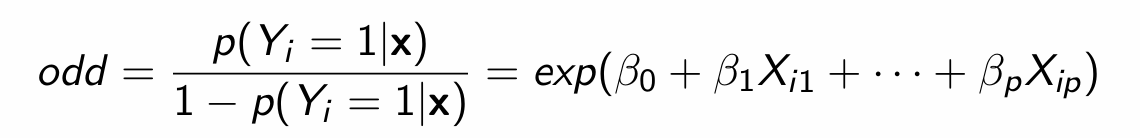

In [ ]:
# Encontromaos la prediccion de los grupos en la muestra test
y_pred_logr = logr.predict(X_test)


print('--------------------')
print('Tabla de confusión')
print('-------------------')
CM = confusion_matrix(y_test,y_pred_logr)  # Matriz de confusión
print(CM)
print('--------------------')
print('Reporte de medidas de desempeño')
print('-------------------')
print('accuracy: ', accuracy_score(y_test,y_pred_logr))

--------------------
Tabla de confusión
-------------------
[[54  0]
 [ 2  4]]
--------------------
Reporte de medidas de desempeño
-------------------
accuracy:  0.9666666666666667


In [ ]:
# en este caso proponemos una búsqueda de la mejor estimación del modelo logístico armando una grilla de parámetros
# definimos en solver distintos métodos de estimación posibles de la logística que permite la función LogisticRegression  del paquete sklearn.linear
solver = ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
# y en C se definen parámetros de regularización que aceleran el proceso de estimación (a medida que son más grandes) en este caso se proponen un vector de valores
# aleatorios espaciados según una escala logarítmica ( podrían haberse seleccionado en forma uniforme que son los nros aleatorios que se conocen comunmente).
C = np.logspace(-2, 10, 13)
# definimos el modelo a estimar LogisticRegression previo estandarizar los datos con StandardScaler
pipe_lr = Pipeline([('sc', StandardScaler()),
    ('LR', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
# definimos los vectores de parámetros para hacer las estimaciones
params_lr = {
    'LR__C': C,
    'LR__solver': solver
    }

# proponemos la busqueda del mejor modelo según el resultado de la mejor clasificación (accuracy) con la tasa crosvalidada (GridSearchCV)
search_lr = GridSearchCV(estimator=pipe_lr,
                      param_grid=params_lr,
                      cv = 5,
                      return_train_score=True)

search_lr.fit(X_train, y_train)
print(f" Best score is: {search_lr.best_score_} with parameters: {search_lr.best_params_}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

 Best score is: 1.0 with parameters: {'LR__C': np.float64(0.01), 'LR__solver': 'newton-cg'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
#Para confirmar que no hay sobreajuste:
y_pred = search_lr.best_estimator_.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
#Dado que el acurracy en test tambien es uno el modelo realmente generaliza bien

Test accuracy: 1.0


In [ ]:
#Estimacion del modelo indicado
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))])

lr = LogisticRegression(C=10, max_iter=1000, solver ='liblinear' )
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

coef_reg=pd.DataFrame(np.exp(lr.coef_))
coef_reg.columns = ['ant_meses', 'porc_compra_dig', 'porc_cobertura_surtido', 'minutos_plat',
       'min_pagina', 'visitas_unicas', 'prod_agregados', 'prod_removidos',
       'duracion_compra']

coef_reg

,ant_meses,porc_compra_dig,porc_cobertura_surtido,minutos_plat,min_pagina,visitas_unicas,prod_agregados,prod_removidos,duracion_compra
0,1.000927,0.984508,0.984738,1.236095,1.027537,0.753911,0.880812,1.046421,3451.683159


In [ ]:
coef_vertical = coef_reg.T
coef_vertical.columns = ['Coeficiente']  # nombre de la columna con los valores
coef_vertical.index.name = 'Variable'    # nombre de la columna con los nombres de las variables
print(coef_vertical)

                        Coeficiente
Variable                           
ant_meses                  1.000927
porc_compra_dig            0.984508
porc_cobertura_surtido     0.984738
minutos_plat               1.236095
min_pagina                 1.027537
visitas_unicas             0.753911
prod_agregados             0.880812
prod_removidos             1.046421
duracion_compra         3451.683159


In [ ]:
# Variables independientes
X = df[['ant_meses', 'porc_compra_dig', 'porc_cobertura_surtido', 'minutos_plat',
       'min_pagina', 'visitas_unicas', 'prod_agregados', 'revome_from_cart_count',
       'duracion_compra']]
X = sm.add_constant(X)
y = df['compra_realizada'] # variable dependiente

# Modelo 1 - todas las variables
model_1 = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.231757
         Iterations 9


In [ ]:
#Con los coeficientes estimados del modelo,muestra el efecto porcentual o la razon de odds
# Calcular Odds Ratios y sus intervalos de confianza
odds_ratios = np.exp(model_1.params)
conf_int = np.exp(model_1.conf_int())

# Combinar todo en un DataFrame más claro
odds_ratios_df = pd.DataFrame({
    "Coeficiente (log-odds)": model_1.params,
    "Odds Ratio": odds_ratios,
    "IC 2.5%": conf_int[0],
    "IC 97.5%": conf_int[1]
})

print("\n=== Odds Ratios ===")
print(odds_ratios_df)

# You're looking at the Odds Ratios for modelo2. In a logistic regression, the modelo2.params are the coefficients in the log-odds scale. Applying np.exp() converts these coefficients into odds ratios, which are easier to interpret.

# Here's what each value means for the odds of compra_realizada = 1 (a purchase being made), holding all other variables constant:

# Intercept (0.062002): This represents the odds of a purchase being made when all other numerical predictors are zero, and categorical predictors are at their reference level. It's often not directly meaningful in a practical sense.

# cliente_tamaño[T.Medium] (5.724701): The odds of a purchase being made for customers with cliente_tamaño = Medium are approximately 5.72 times higher than for the baseline category of customer size (which, by default in statsmodels, is typically the category that's alphabetically first or last and thus omitted from the coefficient list – in this case, likely 'Large').

# cliente_tamaño[T.Small] (5.769693): The odds of a purchase being made for customers with cliente_tamaño = Small are approximately 5.77 times higher than for the baseline customer size category.

# cliente_tamaño[T.Very Large] (2.054166): The odds of a purchase being made for customers with cliente_tamaño = Very Large are approximately 2.05 times higher than for the baseline customer size category.

# porc_compra_dig (0.992372): For every one-unit increase in the porc_compra_dig (percentage of digital purchases), the odds of a purchase being made are multiplied by 0.992. Since this value is very close to 1 (and slightly below), it suggests a very slight, almost negligible, decrease in the odds of making a purchase with an increase in this percentage.

# porc_cobertura_surtido (33.646993): For every one-unit increase in porc_cobertura_surtido (percentage of assortment coverage), the odds of a purchase being made are multiplied by 33.65. This indicates a very strong positive association; however, based on the p-value from the model summary (which was 0.414), this effect is not statistically significant, meaning we cannot confidently say it's a real effect in the population.

# duracion_compra (0.966418): For every one-unit increase in duracion_compra (duration of purchase), the odds of a purchase being made are multiplied by 0.966. This suggests a slight decrease in the odds of purchase as the duration increases. The p-value for this variable (0.080) indicates it's marginally significant at an alpha level of 0.10, but not at 0.05.


=== Odds Ratios ===
                        Coeficiente (log-odds)  Odds Ratio   IC 2.5%  \
const                                 2.529586   12.548308  0.474406   
ant_meses                            -0.019598    0.980593  0.849675   
porc_compra_dig                      -0.006505    0.993516  0.966482   
porc_cobertura_surtido                4.612347  100.720270  0.129833   
minutos_plat                         -0.005223    0.994791  0.985937   
min_pagina                            0.127523    1.136011  0.982705   
visitas_unicas                       -0.350366    0.704430  0.560403   
prod_agregados                       -0.202305    0.816846  0.720170   
revome_from_cart_count                0.114039    1.120796  1.043681   
duracion_compra                       0.007750    1.007781  0.972339   

                            IC 97.5%  
const                     331.909674  
ant_meses                   1.131681  
porc_compra_dig             1.021307  
porc_cobertura_surtido  78135.

In [ ]:
print('--------------------')
print('Tabla de confusión')
print('-------------------')
CM = confusion_matrix(y_test,y_pred_lr)  # Matriz de confusión
print(CM)
print('--------------------')
print('Reporte de medidas de desempeño')
print('-------------------')
print(classification_report(y_test,y_pred_lr, digits = 2))
print('accuracy: ', accuracy_score(y_test,y_pred_lr))

--------------------
Tabla de confusión
-------------------
[[54  0]
 [ 1  5]]
--------------------
Reporte de medidas de desempeño
-------------------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       1.00      0.83      0.91         6

    accuracy                           0.98        60
   macro avg       0.99      0.92      0.95        60
weighted avg       0.98      0.98      0.98        60

accuracy:  0.9833333333333333


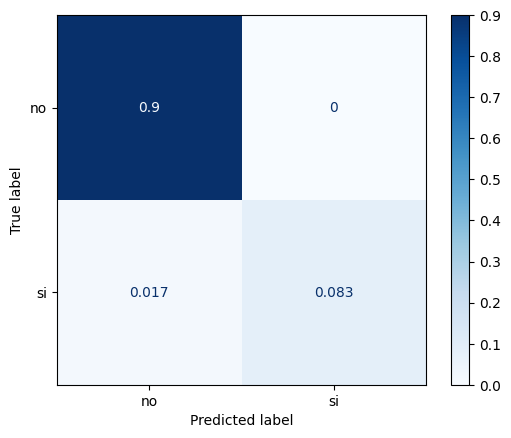

In [ ]:
# gráfico de la matriz de confusión en proporciones (normalize{‘true’, ‘pred’, ‘all’}, default=None)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr, display_labels=['no', 'si'],normalize='all',cmap='Blues')
plt.show()

In [ ]:
predicciones = modelo2.predict(exog = df)

In [ ]:
df['compras_pred'] = predicciones
tabla_compras=pd.DataFrame(predicciones)
tabla_compras['compras_obs'] = df.compra_realizada

tabla_compras.columns = ['compras_pred','compras_obs']
tabla_compras.head(20)

,compras_pred,compras_obs
0,0.159713,0
1,0.025142,0
2,0.101288,0
3,0.184365,1
4,0.035117,0
5,0.158489,0
6,0.058846,0
7,0.048566,0
8,0.342790,1
9,0.102949,0


In [ ]:
#Creiterio de clasificacion del modelo Log

clasificacion = np.where(predicciones<0.5, 0, 1)
df['compras_modelo'] = clasificacion

# Medir la concordancia del modelo con la clasificacion

X_test = sm.add_constant(df, prepend=True)
predicciones = modelo2.predict(exog = df)
clasificacion = np.where(predicciones<0.5, 0, 1)
accuracy = accuracy_score(
            y_true    = df.compra_realizada,
            y_pred    = clasificacion,
            normalize = True
           )
print("")
print(f"El porcentaje de concordancia del test es: {100*accuracy}%")


El porcentaje de concordancia del test es: 90.0%


<Axes: >

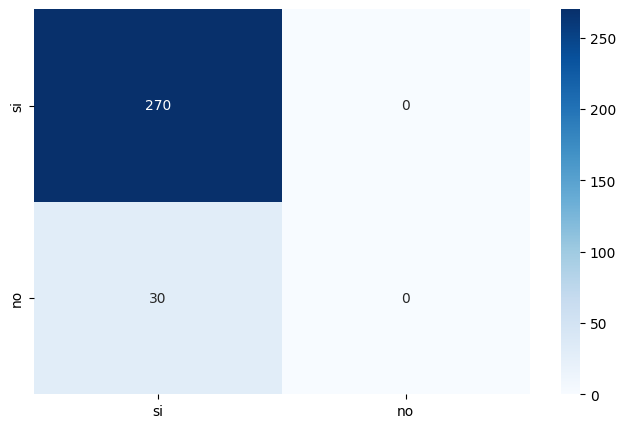

In [ ]:
#Matriz de Confusion, para graficar claramente la tasa de clasificacion (accuracy)
cm = confusion_matrix(df.compra_realizada,clasificacion)
conf_matrix = pd.DataFrame(data=cm,columns=['si','no'], index=['si','no'] )
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True,fmt='d',cmap="Blues")

In [ ]:
#Otras medidas de desempeño son las de Sensibilidad (TP/P) y Especificidad (TN/N)

VN=cm[0,0]
VP=cm[1,1]
FN=cm[1,0]
FP=cm[0,1]
sensibilidad=VP/float(VP+FN)
especificidad=VN/float(VN+FP)

print('Sensibilidad Ratio: ',sensibilidad)
print('Especificidad Ratio: ', especificidad)

Sensibilidad Ratio:  0.0
Especificidad Ratio:  1.0


## 6.2 Curva de ROC

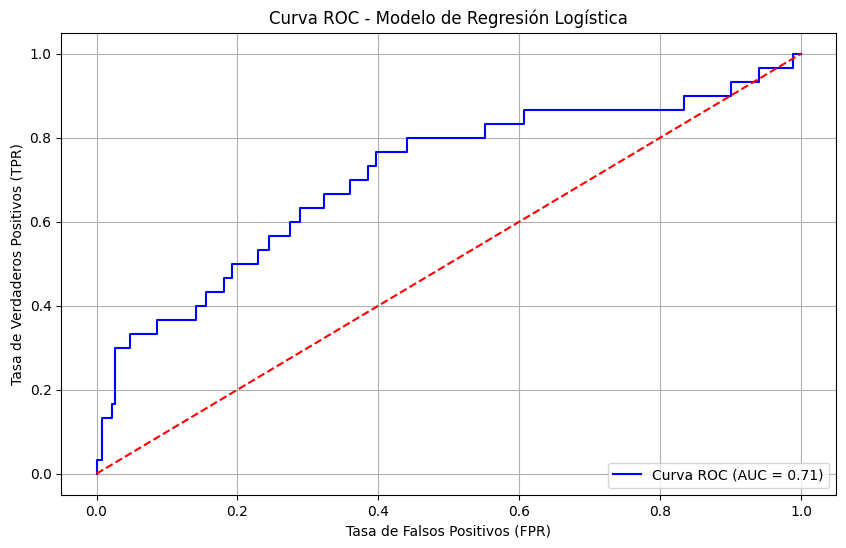

In [ ]:
#Curva de ROC
predicciones = modelo2.predict(df)
y_true = df['compra_realizada']

fpr, tpr, thresholds = roc_curve(y_true, predicciones)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()